# **Human Pose Estimation for Sports Biomechanics using YOLO**

Author: Souvik Mandal, PhD [LinkedIn](https://www.linkedin.com/in/souvik-mandal-phd/)


In this notebook, we will dive into the world of **Computer Vision** to extract the movement patterns of athletes. This data will allow you to analyze athletic performance, swing mechanics, and body kinematics. Before we touch the code, it is vital to understand the "brain" of the AI you are using. Pose estimation has evolved rapidly from simple shape detection to complex models that understand how human joints relate to each other in 3D space.

### **Understanding the AI Leaderboard (2026 Edition)**

To choose the right tool for your specific sport (whether it's a single-person golf swing or a 22-person soccer match), you need to compare models across several dimensions. Below is a comprehensive guide to the state-of-the-art models available today.

| Model | Architecture Type | Source / Creator | Year (First/Latest) | Pros | Cons | Speed | Accuracy | Ease of Deployment | Best Use Case | Documentation |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **YOLO26-Pose** | **Single-Stage** (CNN/Hybrid) | [Ultralytics](https://github.com/ultralytics/ultralytics) | 2016 / 2026 | Natively end-to-end; extremely fast; built-in tracking. | Can be "jittery" in extremely crowded scenes. | **Ultra High** | High | **Very Easy** | Real-time edge AI, live sports broadcasting. | [Docs](https://docs.ultralytics.com/tasks/pose/) |
| **MediaPipe (BlazePose)** | **Two-Stage** (Detector + Tracker) | [Google](https://github.com/google-ai-edge/mediapipe) | 2020 / 2026 | **33 Landmarks** (includes fingers/toes); runs in browsers. | Optimized for **single-person**; struggles with overlap. | **Ultra High** | Moderate | **Very Easy** | Mobile fitness apps, Yoga, rehab tracking. | [Docs](https://developers.google.com/mediapipe/solutions/vision/pose_landmarker) |
| **ViTPose++** | **Vision Transformer** (ViT) | [Shanghai AI Lab](https://github.com/ViTAE-Transformer/ViTPose) | 2022 / 2026 | SOTA accuracy; handles multiple datasets; stable keypoints. | Very heavy; requires high-end GPU. | Low | **Ultra High** | Moderate | Professional biomechanics research. | [Paper](https://arxiv.org/abs/2212.08496) |
| **RTMPose** | **Top-Down** (SimCC Head) | [OpenMMLab](https://github.com/open-mmlab/mmpose) | 2023 / 2025 | Incredible speed/accuracy balance; avoids heatmap lag. | Requires separate person detector. | High | High | Moderate | Industrial production, high-speed sports tracking. | [Docs](https://mmpose.readthedocs.io/en/latest/user_guides/rtmpose.html) |
| **HRNet** | **High-Resolution** (Parallel Net) | [Microsoft](https://github.com/HRNet/HRNet-Human-Pose-Estimation) | 2019 / 2024 | Maintains high-res features; very reliable "gold standard." | Computationally heavy compared to mobile nets. | Moderate | High | Moderate | Medical/Gait analysis, precision joint angles. | [Paper](https://arxiv.org/abs/1908.07919) |
| **MoveNet** | **Bottom-Up** (Heatmap-based) | [Google](https://github.com/tensorflow/tfjs-models/tree/master/pose-detection/src/movenet) | 2021 / 2025 | Highly optimized for browsers and mobile phones. | Primarily single-person; lower precision. | **Ultra High** | Moderate | **Very Easy** | Mobile fitness apps, Yoga/Pilates home tracking. |[TF Hub](https://www.tensorflow.org/hub/tutorials/movenet) |
| **AlphaPose** | **Top-Down** (Two-Stage) | [SJTU (MVIG)](https://github.com/MVIG-SJTU/AlphaPose) | 2017 / 2025 | Excellent multi-person tracking; handles overlap/occlusion. | Heavier resource usage; complex setup. | Moderate | High | Difficult | Crowd analysis, contact sports (Rugby, Wrestling). | [Docs](https://www.mvig.org/research/alphapose.html) |
| **Poseidon** | **Temporal Transformer** | [Univ. of Salerno](https://github.com/CesareDavidePace/poseidon) | 2025 / 2026 | Uses multi-frame "memory" to see through hidden limbs. | Newer research model; higher latency. | Moderate | **Ultra High** | Difficult | Fast-action sports (Baseball pitching, Gymnastics). | [Paper](https://arxiv.org/abs/2501.08446) |

---

### **Key Terminology for Your Project**

As you compare these models, you will encounter specific technical metrics. Understanding these will help you justify why you chose a specific model size (Nano vs. Large) for your student project:

* **mAPpose 50-95 (e2e):** *Mean Average Precision*. This is the AI's "final grade." It measures how often the predicted joint is within a certain distance of the actual joint. "50-95" means it averages the accuracy across very easy (50%) and very strict (95%) thresholds.

* **mAPpose 50 (e2e):** A more "forgiving" score. It counts a detection as correct if the AI is roughly in the right area. If the model guesses the joint location and it overlaps the true location by at least 50%, it gets a passing grade.

* **Speed CPU ONNX (ms):** How long it takes to process one frame on a standard laptop (no graphics card). Lower is better. As 1000ms = 1 second, if a model takes 100ms, it processes at 10 Frames Per Second. If it's **33ms** or lower, you can run at **30 FPS** (real-time).

* **Speed T4 TensorRT10 (ms):** The speed when using a professional NVIDIA GPU. This is usually 10x to 50x faster than a CPU.

* **Params (M):** Millions of "Parameters." Think of this as the size of the AI's brain. In general, more parameters = better, but slower and requires more memory. It can vary from **Nano** (~3M) to **Extra Large** (~60M).

* **FLOPs (B):** "Billions of Floating Point Operations" or billions of math operations per second. Higher FLOPs mean your computer will work harder and generate more heat, and your computer's fan is going to spin a lot louder!

* **Size (pixels):** The resolution the image is resized to before the AI processes it. Usually, 640 means the video is resized to $640 \times 640$. Higher resolution helps find small objects (like a ball) but slows down the speed.

---

---

In this notebook, we will extract the exact mathematical coordinates of human joints from video files using YOLO.

## Why YOLO26?
You may have heard of other pose estimation tools. While many are incredibly fast and great for single-person, or webcam-based applications (like a fitness app on your phone), it traditionally struggles when multiple people are in the frame, or if it doesn't know exactly where to look.

We are using **YOLO26-pose** (You Only Look Once) as YOLO is built differently. It is fundamentally an **Object Detection** model. 
1. First, it scans the entire image to find *all* the humans.
2. Then, it draws a bounding box around every person it finds.
3. Finally, it calculates the skeletal keypoints *inside* each of those boxes.

This makes YOLO incredibly robust for sports where multiple people are moving around. The beautiful thing about this model is that it is "pre-trained." Researchers have already shown it hundreds of thousands of images of humans, so it already knows how to find 17 specific body joints (called **keypoints**) right out of the box.

If you have not already, please install the `ultralytics` library, which contains the YOLO models.

In [ ]:
# Install the necessary computer vision libraries
%pip install ultralytics opencv-python matplotlib

#In case you want to use this environment for data analysis and visualization, you can also install the following libraries
#%pip install pandas numpy tqdm matplotlib seaborn 

## 1. Loading the Model

Now we will import the library and load our model. We are using `yolo11n-pose.pt`. 
* **26** is the version.
* **n** stands for "nano", meaning it's the smallest, fastest version (perfect for processing video quickly on a laptop).
* **pose** means it's specifically designed to find skeletal keypoints, not just draw boxes around things.

* You can use the other models as follows. Change the name of the model accordingly in the next cell.
- yolo26n-pose.pt
- yolo26s-pose.pt
- yolo26m-pose.pt
- yolo26l-pose.pt
- yolo26x-pose.pt

* Please visit the [YOLO official website](https://docs.ultralytics.com/models/yolo26/) to check the other models.


In [1]:
from ultralytics import YOLO

# Load the pre-trained pose model
model = YOLO("yolo26n-pose.pt")

## 2. Running Inference (Making Predictions)

Let's test the AI on a single image. You can upload an image of a person to your notebook and change the file name below, or we can use a sample image provided by the library.

When we pass an image through the model, it returns a `results` object containing all the math and coordinates it calculated.


image 1/1 /Users/souvikmandal/Documents/S06_Teaching_Mentoring_Talks/LS100/2026_Sem01/media/Henry/Position_right_cam_corrected.jpg: 384x640 1 person, 39.0ms
Speed: 1.7ms preprocess, 39.0ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)


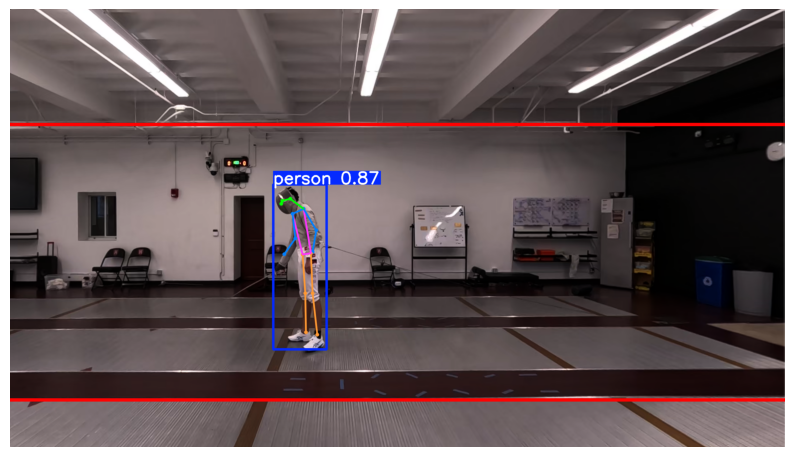

In [3]:
import matplotlib.pyplot as plt
import cv2

# Run the model on a sample image (replace with your own image path like 'swing.jpg')

image_source = "/Users/souvikmandal/Documents/S06_Teaching_Mentoring_Talks/LS100/2026_Sem01/media/Henry/Position_right_cam_corrected.jpg" 

# The model does the heavy lifting here
results = model(image_source)

# Grab the first (and only) result
result = results[0]

# YOLO has a built-in tool to draw the skeleton on the image
annotated_image = result.plot()

# Convert colors from BGR (OpenCV default) to RGB (Matplotlib default) for displaying
annotated_image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)

# Display the image
plt.figure(figsize=(10, 8))
plt.imshow(annotated_image_rgb)
plt.axis('off')
plt.show()

In [8]:
# --- STEP 0: DYNAMIC HARDWARE DETECTION ---
import ultralytics; ultralytics.checks()
# Detect total available cores
import os
total_cores = os.cpu_count()
print(f"\nTotal CPU cores detected: {total_cores}")

Ultralytics 8.4.27 🚀 Python-3.12.12 torch-2.11.0 CPU (Apple M2 Max)
Setup complete ✅ (12 CPUs, 64.0 GB RAM, 1072.7/1858.2 GB disk)

Total CPU cores detected: 12


## 3. Configure Video Inputs and YOLO Settings

This cell prepares the pipeline before full-frame processing begins.

The following cell will:
1. Accept either a single video path or a folder containing multiple videos (`INPUT_VIDEO_PATH`).
2. Collect and validate supported video files (`INPUT_VIDEO_FILES`).
3. Print which video files were found for analysis.
4. Set YOLO pose-tracking parameters (model, confidence, IoU, image size, tracker).
5. Create default output file paths (`RAW_CSV_PATH`, `HEALED_CSV_PATH`, `FINAL_CSV_PATH`, `OUTPUT_VIDEO_PATH`) for downstream steps.
6. Define the COCO keypoint name list (`KEYPOINT_NAMES`).

In [ ]:
import os
import torch
import pandas as pd
from tqdm import tqdm
from ultralytics import YOLO

# ==========================================
# MASTER CONTROL PANEL
# ==========================================
# INPUT: Set this to either:
# 1) A single video file path, OR
# 2) A folder path that contains multiple videos
INPUT_VIDEO_PATH = "/Users/souvikmandal/Documents/S06_Teaching_Mentoring_Talks/LS100/2026_Sem01/media/Henry/test_videos"  # <-- CHANGE THIS TO YOUR VIDEO OR FOLDER PATH

# Supported video formats (lowercase extensions)
VIDEO_EXTENSIONS = (".mp4", ".mov", ".avi", ".mkv", ".m4v", ".mpg", ".mpeg", ".wmv")


def collect_input_videos(input_path, extensions=VIDEO_EXTENSIONS):
    """Return a sorted list of video files from a single file path or directory path."""
    normalized_path = os.path.abspath(os.path.expanduser(input_path))

    if os.path.isfile(normalized_path):
        if normalized_path.lower().endswith(extensions):
            return [normalized_path]
        raise ValueError(f"Input file is not a supported video type: {normalized_path}")

    if os.path.isdir(normalized_path):
        video_files = [
            os.path.join(normalized_path, file_name)
            for file_name in sorted(os.listdir(normalized_path))
            if os.path.isfile(os.path.join(normalized_path, file_name))
            and file_name.lower().endswith(extensions)
        ]
        if not video_files:
            raise ValueError(
                f"No video files found in folder: {normalized_path}\n"
                f"Expected extensions: {extensions}"
            )
        return video_files

    raise FileNotFoundError(f"Path does not exist: {normalized_path}")


INPUT_VIDEO_FILES = collect_input_videos(INPUT_VIDEO_PATH)
print(f"Found {len(INPUT_VIDEO_FILES)} video(s) for analysis.")
for video_file in INPUT_VIDEO_FILES:
    print(f"  - {os.path.basename(video_file)}")

# AI Model Settings
YOLO_MODEL = "yolo26n-pose.pt" # 'n' stands for nano (fastest). You could change this to 's' or 'l' for large (most accurate).
CONFIDENCE = 0.4               # The AI must be at least 40% sure it sees a person before it records data.
IOU_THRESHOLD = 0.5            # Intersection Over Union: If two bodies overlap by more than 50%, it treats them as separate entities.
IMAGE_SIZE = 640 # Use 640 for faster processing but less accuracy. Use 832 or 1280 pixels to enable the model detecting overlapping limbs better.
TRACKER_FILE = "custom_tracker.yaml" # The specific rulebook (like BoT-SORT) the AI uses to remember who is who across frames.

# --- DEFAULT FILE NAMING (for downstream cells) ---
# We keep one "active" video path so the rest of the notebook can continue to run unchanged.
DEFAULT_VIDEO_PATH = INPUT_VIDEO_FILES[0]
INPUT_VIDEO_PATH = DEFAULT_VIDEO_PATH
base_name = os.path.splitext(DEFAULT_VIDEO_PATH)[0]
RAW_CSV_PATH = f"{base_name}_raw_tracks.csv"
HEALED_CSV_PATH = f"{base_name}_healed_tracks.csv"
FINAL_CSV_PATH = f"{base_name}_final_kinematics.csv"
OUTPUT_VIDEO_PATH = f"{base_name}_processed.mp4"

# --- GLOBAL CONSTANTS ---
# CLARIFICATION: These are the 17 standard joints the COCO dataset requires YOLO to track.
KEYPOINT_NAMES = [
    "nose", "left_eye", "right_eye", "left_ear", "right_ear",
    "left_shoulder", "right_shoulder", "left_elbow", "right_elbow",
    "left_wrist", "right_wrist", "left_hip", "right_hip",
    "left_knee", "right_knee", "left_ankle", "right_ankle"
]


Found 4 video(s) for analysis.
  - LS100_FInalData_1.mov
  - LS100_FInalData_2.mov
  - LS100_FInalData_3.mov
  - LS100_FInalData_4.mov


### Step 1: Raw Keypoint Extraction with YOLO Tracking

This step runs the core pose-tracking engine on each input video and saves frame-by-frame raw coordinates.

What the next code cell does:
1. Defines `step_1_extract_raw_data(...)` to process one video end-to-end.
2. Detects hardware automatically (CUDA GPU if available; otherwise CPU, including a stable CPU fallback on Apple Silicon).
3. Reads video metadata (`FPS`, width, height, total frame count) using OpenCV.
4. Runs `YOLO(...).track(...)` with your dashboard settings (`CONFIDENCE`, `IOU_THRESHOLD`, `IMAGE_SIZE`, `TRACKER_FILE`).
5. Iterates through each frame result, extracts tracked person IDs and 17 keypoints, and builds a raw pose table.
6. Saves one raw CSV per video (e.g., `*_raw_tracks.csv`).
7. Repeats this for all videos in `INPUT_VIDEO_FILES`, stores per-video run info in `video_run_registry`, and combines all raw outputs into `combined_raw_df`.
8. Keeps backward compatibility by setting default downstream variables (`RAW_CSV_PATH`, `FPS`, `WIDTH`, `HEIGHT`, `TOTAL_FRAMES`) from the first selected input video.

In [ ]:

# ==========================================
# STEP 1: RAW EXTRACTION (Optimized YOLO Engine)
# ==========================================
def step_1_extract_raw_data(video_path, output_csv, model_name, conf, iou, imgsz, tracker, keypoints_list):
    """
    Extracts video properties, dynamically detects hardware, runs the specified 
    YOLO tracking model using Dashboard settings, and saves raw coordinates to a CSV.
    """
    print(f"\nSTEP 1: Extracting Raw Coordinates from {os.path.basename(video_path)}...")
    
# --- DYNAMIC HARDWARE DETECTION (PATCHED FOR MAC STABILITY) ---
    # STUDENT CLARIFICATION: We check for Nvidia GPUs (CUDA). If on a Mac, 
    # we default to CPU because PyTorch's MPS (Metal) backend currently has 
    # known crash issues with YOLO tracking operations.
    if torch.cuda.is_available():
        compute_device = 'cuda'
        print("Hardware config: NVIDIA CUDA GPU detected! Fast processing enabled.")
    elif torch.backends.mps.is_available():
        compute_device = 'cpu' # FORCED OVERRIDE: Bypassing 'mps' to prevent kernel crashes on Mac.
        total_cores = os.cpu_count()
        use_threads = total_cores - 2 if total_cores > 4 else total_cores
        torch.set_num_threads(use_threads)
        print(f"Hardware config: Apple Silicon detected! Using CPU ({use_threads}/{total_cores} threads) for stability.")
    else:
        compute_device = 'cpu'
        total_cores = os.cpu_count()
        use_threads = total_cores - 2 if total_cores > 4 else total_cores
        torch.set_num_threads(use_threads)
        print(f"Hardware config: No GPU found. Falling back to CPU ({use_threads}/{total_cores} threads).")

    # --- VIDEO PARAMETER EXTRACTION ---
    cap = cv2.VideoCapture(video_path)
    video_fps = cap.get(cv2.CAP_PROP_FPS)
    video_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    video_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release() 
    
    print(f"Video Stats: {total_frames} frames | {video_fps} FPS | Res: {video_width}x{video_height}")

    model = YOLO(model_name)
    
    # --- AI TRACKING ---
    # CLARIFICATION: This is where the actual AI engine runs using the variables from your Master Control Panel.
    results = model.track(
        source=video_path,
        conf=conf,             # From dashboard
        iou=iou,               # From dashboard
        imgsz=imgsz,           # From dashboard
        tracker=tracker,       # From dashboard
        persist=True,          # CRITICAL: Tells the AI to remember the person's ID from the previous frame.
        device=compute_device, # Uses the hardware we automatically detected above.
        stream=True,           # Processes one frame at a time so your computer's RAM doesn't crash.
        verbose=False          # Hides the "spammy" AI text output in the terminal.
    )
    
    pose_data = []
    
    for frame_idx, result in enumerate(tqdm(results, total=total_frames, desc="AI Tracking")):
        res_cpu = result.cpu()
        
        if res_cpu.boxes is not None and res_cpu.boxes.id is not None:
            track_ids = res_cpu.boxes.id.int().tolist()
            frame_keypoints = res_cpu.keypoints.xy.numpy() 
            
            for i, track_id in enumerate(track_ids):
                person_kpts = frame_keypoints[i]
                
                row = {"frame": frame_idx, "raw_id": track_id}
                
                for kpt_idx, (x, y) in enumerate(person_kpts):
                    if kpt_idx < len(keypoints_list):
                        row[f"{keypoints_list[kpt_idx]}_x"] = x
                        row[f"{keypoints_list[kpt_idx]}_y"] = y
                        
                pose_data.append(row)

    df = pd.DataFrame(pose_data)
    df.to_csv(output_csv, index=False)
    print(f"   ✅ Raw data saved to: {os.path.basename(output_csv)}")
    
    return df, video_fps, video_width, video_height, total_frames

# --- EXECUTE STEP 1 FOR ALL INPUT VIDEOS ---
video_run_registry = {}
all_raw_dfs = []

for current_video_path in INPUT_VIDEO_FILES:
    current_base_name = os.path.splitext(current_video_path)[0]
    current_raw_csv_path = f"{current_base_name}_raw_tracks.csv"

    current_raw_df, current_fps, current_width, current_height, current_total_frames = step_1_extract_raw_data(
        current_video_path,
        current_raw_csv_path,
        YOLO_MODEL,
        CONFIDENCE,
        IOU_THRESHOLD,
        IMAGE_SIZE,
        TRACKER_FILE,
        KEYPOINT_NAMES
    )

    video_run_registry[current_video_path] = {
        "raw_csv": current_raw_csv_path,
        "fps": current_fps,
        "width": current_width,
        "height": current_height,
        "total_frames": current_total_frames
    }

    all_raw_dfs.append(current_raw_df.assign(source_video=os.path.basename(current_video_path)))

# Optional combined table (all videos together)
combined_raw_df = pd.concat(all_raw_dfs, ignore_index=True) if all_raw_dfs else pd.DataFrame()

# Keep backward compatibility for downstream cells (default = first input video)
default_info = video_run_registry[DEFAULT_VIDEO_PATH]
RAW_CSV_PATH = default_info["raw_csv"]
FPS = default_info["fps"]
WIDTH = default_info["width"]
HEIGHT = default_info["height"]
TOTAL_FRAMES = default_info["total_frames"]

print("\nMulti-video raw extraction complete.")
print(f"Default downstream target remains: {os.path.basename(DEFAULT_VIDEO_PATH)}")
print(f"RAW_CSV_PATH now points to: {os.path.basename(RAW_CSV_PATH)}")

In [ ]:
# Check the columns of the raw CSV to ensure data was extracted correctly
print(pd.read_csv(RAW_CSV_PATH).columns)

Index(['frame', 'raw_id', 'nose_x', 'nose_y', 'left_eye_x', 'left_eye_y',
       'right_eye_x', 'right_eye_y', 'left_ear_x', 'left_ear_y', 'right_ear_x',
       'right_ear_y', 'left_shoulder_x', 'left_shoulder_y', 'right_shoulder_x',
       'right_shoulder_y', 'left_elbow_x', 'left_elbow_y', 'right_elbow_x',
       'right_elbow_y', 'left_wrist_x', 'left_wrist_y', 'right_wrist_x',
       'right_wrist_y', 'left_hip_x', 'left_hip_y', 'right_hip_x',
       'right_hip_y', 'left_knee_x', 'left_knee_y', 'right_knee_x',
       'right_knee_y', 'left_ankle_x', 'left_ankle_y', 'right_ankle_x',
       'right_ankle_y'],
      dtype='str')


---

### Step 2: Identity Healing & Smart Anchoring

**The Problem: "Clinch Amnesia" & "The Walkaway"**
Combat sports are chaotic. When fighters clinch, grapple, or obscure each other from the camera, the AI briefly loses sight of them. Worse, the moving fighter often strikes, walks completely out of the camera frame, and re-enters seconds later. 

When this happens, the raw tracking data treats them as a brand-new person, leaving us with fragmented IDs (e.g., `human_1`, `human_2`, `human_3`). To fix this, we will stitch these broken trajectories back together in three phases:

**1. Finding the Center of Mass (The Torso)**
Raw tracking data gives us points for wrists, ankles, and noses. Because limbs move wildly during a strike, they are terrible points to track for overall body movement. First, our code will average the coordinates of the shoulders and hips to calculate a highly stable "Torso Center" for each person.

**2. The Hungarian Algorithm (Connecting the Dots)**
Next, we use a classic mathematical optimization method called the Hungarian Algorithm to fix minor ID swaps. 
* It looks at the last known position of a fighter and compares it to unidentified bodies in the current frame.
* It calculates the physical pixel distance and finds the most logical 1-to-1 pairing.
* We apply a `max_distance` speed limit (100 pixels) so the model doesn't accidentally "teleport" a fighter across the screen if they temporarily leave the frame.

**3. Smart Anchoring (The Process of Elimination)**|
Finally, we need to definitively lock in who is the stationary target (like a coach holding mitts) and who is the moving fighter. Since we know the moving fighter often leaves the frame, we can't just count on having only two IDs. Instead, we use a smart process of elimination:
* **Filter Glitches:** We ignore any ID that appears for less than 15 frames (half a second) to filter out AI ghost detections (like a referee's foot).
* **Find the Anchor:** We look at the total variance (spread of movement) for the remaining IDs over the entire video. The person who moved the least is mathematically locked in as `human_1` (Stationary).
* **Process of Elimination:** Since we know `human_1` is the stationary target, *any other valid ID* must be our moving fighter! We merge all remaining valid tracks into `human_2`. This perfectly stitches together their data, even if they left the frame and came back as a "new" person!

In [ ]:
from scipy.optimize import linear_sum_assignment

def heal_and_anchor_identities(input_csv, output_csv, 
                               frame_col='frame', 
                               max_distance=100,
                               min_valid_frames=15, 
                               stationary_name="human_1", 
                               moving_name="human_2"):
    """
    Calculates torso centers (ignoring zero-drops), fixes ID swaps, 
    and anchors identities based on who is present at the start of the video.
    """
    print("Starting Identity Healing process...")
    
    df = pd.read_csv(input_csv)
    
    # ---------------------------------------------------------
    # SAFETY CHECK 1: Handle '0.0' limb coordinates
    # We replace 0.0 with NaN so pandas ignores them when averaging,
    # preventing the torso center from teleporting!
    # ---------------------------------------------------------
    print("Calculating stable torso coordinates (ignoring missing limbs)...")
    limb_cols = ['left_shoulder_x', 'right_shoulder_x', 'left_hip_x', 'right_hip_x',
                 'left_shoulder_y', 'right_shoulder_y', 'left_hip_y', 'right_hip_y']
    
    df[limb_cols] = df[limb_cols].replace(0.0, np.nan)
    
    df['torso_x'] = df[['left_shoulder_x', 'right_shoulder_x', 'left_hip_x', 'right_hip_x']].mean(axis=1)
    df['torso_y'] = df[['left_shoulder_y', 'right_shoulder_y', 'left_hip_y', 'right_hip_y']].mean(axis=1)
    
    # Drop rows where ALL torso calculation points were NaN (no torso visible at all)
    df = df.dropna(subset=['torso_x', 'torso_y']).copy()
    
    df['healed_id'] = -1
    active_tracks = {}
    next_new_id = 1
    frames = sorted(df[frame_col].unique())
    
    # --- PHASE 1: HUNGARIAN ALGORITHM (CONNECTING THE DOTS) ---
    print("Connecting trajectories (Hungarian Algorithm)...")
    for frame in frames:
        current_detections = df[df[frame_col] == frame].copy()
        
        if active_tracks and not current_detections.empty:
            track_ids = list(active_tracks.keys())
            track_centers = list(active_tracks.values())
            
            detect_indices = current_detections.index.tolist()
            detect_centers = current_detections[['torso_x', 'torso_y']].values
            
            cost_matrix = np.zeros((len(track_centers), len(detect_centers)))
            
            for i, t_center in enumerate(track_centers):
                for j, d_center in enumerate(detect_centers):
                    distance = np.linalg.norm(np.array(t_center) - np.array(d_center))
                    cost_matrix[i, j] = distance
                    
            row_inds, col_inds = linear_sum_assignment(cost_matrix)
            assigned_detects = set()
            
            for row_idx, col_idx in zip(row_inds, col_inds):
                dist = cost_matrix[row_idx, col_idx]
                
                if dist < max_distance:
                    matched_track_id = track_ids[row_idx]
                    detect_idx = detect_indices[col_idx]
                    
                    df.at[detect_idx, 'healed_id'] = matched_track_id
                    active_tracks[matched_track_id] = detect_centers[col_idx]
                    assigned_detects.add(col_idx)
            
            for j, d_center in enumerate(detect_centers):
                if j not in assigned_detects:
                    detect_idx = detect_indices[j]
                    df.at[detect_idx, 'healed_id'] = next_new_id
                    active_tracks[next_new_id] = d_center
                    next_new_id += 1
                    
        else:
            for idx, row in current_detections.iterrows():
                df.at[idx, 'healed_id'] = next_new_id
                active_tracks[next_new_id] = (row['torso_x'], row['torso_y'])
                next_new_id += 1

    # --- PHASE 2: PRESENCE-BASED ANCHORING ---
    print("Anchoring identities based on video entry...")
    
    # Filter out absolute ghosts (less than 15 frames)
    id_counts = df['healed_id'].value_counts()
    valid_ids = id_counts[id_counts >= min_valid_frames].index.tolist()
    
    # Get the IDs present in the very first recorded frame
    first_frame = frames[0]
    first_frame_ids = df[df[frame_col] == first_frame]['healed_id'].tolist()
    first_frame_valid_ids = [vid for vid in first_frame_ids if vid in valid_ids]
    
    # If there are multiple valid people in frame 0, pick the one who stays the longest
    if len(first_frame_valid_ids) > 1:
        stationary_id = max(first_frame_valid_ids, key=lambda vid: id_counts[vid])
    elif len(first_frame_valid_ids) == 1:
        stationary_id = first_frame_valid_ids[0]
    else:
        # Failsafe
        stationary_id = valid_ids[0] 
        
    # Process of Elimination Assignment
    df['final_id'] = df['healed_id'].apply(
        lambda x: stationary_name if x == stationary_id 
        else (moving_name if x in valid_ids else f"ghost_id_{x}")
    )
    
    # ---------------------------------------------------------
    # SAFETY CHECK 2 & 3: Clean the Output and Enforce 1-to-1 Mapping
    # Drop all ghost tracks and ensure we don't have multiple
    # human_1s or human_2s in the exact same frame!
    # ---------------------------------------------------------
    print("Cleaning up ghost tracks and enforcing 1-to-1 mapping...")
    
    # Keep only the two main actors, drop all the background "ghost_id_X" objects
    df = df[df['final_id'].isin([stationary_name, moving_name])].copy()
    
    # If a frame accidentally has two 'human_2's, keep the one that we matched first
    df = df.drop_duplicates(subset=[frame_col, 'final_id'], keep='first')
    
    df.to_csv(output_csv, index=False)
    print(f"Locked! '{stationary_name}' identified from frame 0. All other valid entries merged into '{moving_name}'.")
    print(f"   ✅ Healing complete! Saved clean backup to {output_csv}")
    
    return df

# ==========================================
# EXECUTE STEP 2 FOR ALL INPUT VIDEOS
# ==========================================
all_healed_dfs = []

for current_video_path in INPUT_VIDEO_FILES:
    current_base_name = os.path.splitext(current_video_path)[0]
    current_raw_csv_path = f"{current_base_name}_raw_tracks.csv"
    current_healed_csv_path = f"{current_base_name}_healed_tracks.csv"

    if not os.path.exists(current_raw_csv_path):
        print(f"⚠️ Skipping Step 2 for {os.path.basename(current_video_path)} (missing raw CSV).")
        continue

    current_healed_df = heal_and_anchor_identities(
        input_csv=current_raw_csv_path, 
        output_csv=current_healed_csv_path,
        frame_col='frame',
        min_valid_frames=15 
    )

    if current_video_path in video_run_registry:
        video_run_registry[current_video_path]["healed_csv"] = current_healed_csv_path
    else:
        video_run_registry[current_video_path] = {"healed_csv": current_healed_csv_path}

    all_healed_dfs.append(current_healed_df.assign(source_video=os.path.basename(current_video_path)))

combined_healed_df = pd.concat(all_healed_dfs, ignore_index=True) if all_healed_dfs else pd.DataFrame()

# Keep backward compatibility for downstream cells (default = first input video)
default_healed_csv = f"{os.path.splitext(DEFAULT_VIDEO_PATH)[0]}_healed_tracks.csv"
HEALED_CSV_PATH = default_healed_csv
df_healed = pd.read_csv(HEALED_CSV_PATH) if os.path.exists(HEALED_CSV_PATH) else pd.DataFrame()

if not df_healed.empty:
    df_healed[['frame', 'raw_id', 'healed_id', 'final_id', 'torso_x', 'torso_y']].head(10)
else:
    print("No healed data available for preview.")

### Step 3: Signal Smoothing (Getting Rid of the Jitters)

**The Problem: "The Amplification of Noise"**
AI pose tracking is incredible, but it isn't perfect. Even when a fighter is standing still, the detected coordinates for their joints will vibrate or "jitter" by a few pixels from frame to frame. 

If we calculate the speed of a strike using raw, jittery data, the math will exaggerate every tiny mistake. A 5-pixel AI glitch in a fraction of a second will look like the fighter's hand suddenly accelerated to 100 miles per hour! 

**The Solution: The Rolling Average Filter**
To fix this, we need to pass our data through a mathematical iron to smooth out the wrinkles. We will use a **Rolling Average Filter**.

* For every single frame, the code will look at a small "window" of frames around it (e.g., the 3 frames before and the 3 frames after).
* It calculates the average position of the joint across that window and replaces the jittery center point with this smooth average.
* **Crucial Rule:** We must apply this filter to `human_1` and `human_2` *separately*. If we don't group the data by their ID first, the code might accidentally average the stationary fighter's coordinates with the moving fighter's coordinates, teleporting them both to the middle of the ring.

We will utilize Pandas' built-in `.rolling()` function. It is incredibly robust, easy to read, and handles edge cases (like the very first frame of the video) gracefully by using the min_periods=1 argument.

In [ ]:
import os
import numpy as np

def smooth_keypoints(input_csv, output_csv, window_size=7):
    """
    Reads the healed tracking data, isolates coordinate columns, 
    and applies a centered rolling average filter to each person
    independently to remove AI tracking jitter.
    """
    print("Starting signal smoothing process...")
    
    # Load the healed data from Step 2
    df = pd.read_csv(input_csv)
    
    # 1. Identify what needs smoothing
    # We want to smooth every column that ends with '_x' or '_y' (noses, wrists, torso, etc.)
    coord_cols = [col for col in df.columns if col.endswith('_x') or col.endswith('_y')]
    
    # 2. Sort the data to ensure chronological order
    # This guarantees frame 10 comes right after frame 9 for each specific person
    df = df.sort_values(by=['final_id', 'frame'])
    
    # 3. Apply the Rolling Average Filter
    # We group by 'final_id' so we don't mix human_1 and human_2's coordinates!
    print(f"Applying rolling average filter (window={window_size} frames)...")
    
    # The lambda function calculates the rolling mean, centered on the current frame
    df[coord_cols] = df.groupby('final_id')[coord_cols].transform(
        lambda x: x.rolling(window=window_size, min_periods=1, center=True).mean()
    )
    
    # 4. Save the finalized kinematic data
    df.to_csv(output_csv, index=False)
    
    print(f"   ✅ Jitters removed! Final smoothed data saved to {output_csv}")
    
    return df

# ==========================================
# EXECUTE STEP 3 FOR ALL INPUT VIDEOS
# ==========================================
all_smoothed_dfs = []

for current_video_path in INPUT_VIDEO_FILES:
    current_base_name = os.path.splitext(current_video_path)[0]
    current_healed_csv_path = f"{current_base_name}_healed_tracks.csv"
    current_final_csv_path = f"{current_base_name}_final_kinematics.csv"

    if not os.path.exists(current_healed_csv_path):
        print(f"Skipping Step 3 for {os.path.basename(current_video_path)} (missing healed CSV).")
        continue

    current_smoothed_df = smooth_keypoints(
        current_healed_csv_path,
        current_final_csv_path,
        window_size=7
    )

    if current_video_path in video_run_registry:
        video_run_registry[current_video_path]["final_csv"] = current_final_csv_path
    else:
        video_run_registry[current_video_path] = {"final_csv": current_final_csv_path}

    all_smoothed_dfs.append(current_smoothed_df.assign(source_video=os.path.basename(current_video_path)))

combined_smoothed_df = pd.concat(all_smoothed_dfs, ignore_index=True) if all_smoothed_dfs else pd.DataFrame()

# Keep backward compatibility for downstream cells (default = first input video)
default_final_csv = f"{os.path.splitext(DEFAULT_VIDEO_PATH)[0]}_final_kinematics.csv"
FINAL_CSV_PATH = default_final_csv
df_smoothed = pd.read_csv(FINAL_CSV_PATH) if os.path.exists(FINAL_CSV_PATH) else pd.DataFrame()

if not df_smoothed.empty:
    df_smoothed[['frame', 'final_id', 'right_wrist_x', 'right_wrist_y', 'torso_x', 'torso_y']].head(10)
else:
    print("No smoothed data available for preview.")

### Step 4: Seperating data for each individual

In this step, we will separate the rows that belongs to each individual and create separate dataframes. This will be helpful for downstream movement analysis of individuals.

In [ ]:
import glob
from pathlib import Path

def split_kinematics_by_healed_id(input_video_path):
    """
    Finds all '*final_kinematics.csv' files in the given directory, 
    sorts them by frame, and splits them into separate CSVs based on unique 'healed_id's.
    """
    # Ensure the path is a Path object for easy manipulation
    INPUT_VIDEO_PATH = os.path.dirname(input_video_path) if os.path.isfile(input_video_path) else input_video_path
    input_dir = Path(INPUT_VIDEO_PATH)
    
    # Search for all matching files in the directory
    search_pattern = input_dir / "*final_kinematics.csv"
    matching_files = glob.glob(str(search_pattern))
    
    if not matching_files:
        print(f"No files found matching '*final_kinematics.csv' in {input_dir}")
        return

    print(f"Found {len(matching_files)} file(s). Starting processing...\n")

    for file_path in matching_files:
        print(f"Processing: {os.path.basename(file_path)}")
        
        # Get the base path and filename without the .csv extension
        base_name = os.path.splitext(file_path)[0]
        
        # Read the CSV
        df = pd.read_csv(file_path)
        
        # Check if required columns exist before processing
        if 'frame' not in df.columns or 'healed_id' not in df.columns:
            print(f"  -> Warning: Missing 'frame' or 'healed_id' in this file. Skipping.")
            continue

        # Sort the rows by 'frame' in ascending order
        df = df.sort_values(by='frame', ascending=True)

        # Get unique healed_ids (dropping any empty/NaN values)
        unique_healed_ids = df['healed_id'].dropna().unique()

        # Create a new CSV for each unique healed_id
        for hid in unique_healed_ids:
            filtered_df = df[df['healed_id'] == hid]
            
            # Format the ID so it doesn't have a trailing ".0" if it's a whole number
            hid_str = str(int(hid)) if hid == int(hid) else str(hid)
            
            # Construct the new output filename
            out_name = f"{base_name}_healed_id_{hid_str}.csv"
            
            # Save it to the same folder
            filtered_df.to_csv(out_name, index=False)
            print(f"  -> Saved: {os.path.basename(out_name)}")
            
    print("\nProcessing complete!")

# Run the function
split_kinematics_by_healed_id(INPUT_VIDEO_PATH)

### Step 5: Visualizing the Healed Skeletons

**The Payoff: Creating the "After" Video**
We have successfully identified the stationary target (`human_1`), isolated our moving fighter (`human_2`), fixed the ID swaps, and ironed out the AI tracking jitters. Now, it is time to prove it.

### Optional: Generating the "Before" Video

**What does raw AI tracking look like?**
Before we clean up the data, let's see what the AI actually "sees" out of the box. We are going to run the raw YOLO26 model on our video and tell it to save the output. 

When you watch this video, pay close attention to the bounding boxes and the ID numbers floating above the fighters. You will likely notice:
* **The Clinch Amnesia:** IDs swapping when the fighters cross paths.
* **The Ghost Detections:** The AI briefly thinking a poster or a referee is one of the fighters.
* **The Jitters:** The skeleton vibrating even when the fighter is still.

This chaotic video is why we needed to build our data pipeline!

In [ ]:
import os
import cv2
from ultralytics import YOLO
from tqdm import tqdm

# ==========================================
# RUN THE OPTIONAL 'BEFORE' VIDEO FOR ALL INPUTS
# ==========================================
model = YOLO(YOLO_MODEL)

for current_video_path in INPUT_VIDEO_FILES:
    video_stem = os.path.splitext(os.path.basename(current_video_path))[0]
    save_name = f"raw_tracking_{video_stem}"

    print(f"Processing raw 'Before' video: {os.path.basename(current_video_path)}")

    # 1. Get total frame count for progress bar
    cap = cv2.VideoCapture(current_video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()

    # 2. Run model and save annotated raw tracking video
    results = model.track(
        source=current_video_path,
        stream=True,         # Processes frame-by-frame (saves RAM)
        verbose=False,       # Silences text spam
        save=True,           # Save the annotated output video
        project='runs',      # Parent folder
        name=save_name,      # Unique folder per input video
        exist_ok=True        # Overwrite folder if it already exists
    )

    # 3. Iterate to execute generator and keep live progress
    for _ in tqdm(results, total=total_frames, desc=f"Raw AI Tracking ({video_stem})"):
        pass

print("✅ Raw 'Before' videos saved under runs/raw_tracking_<video_name>/")

### Step 6: Visualizing the Healed Skeletons

**The Payoff: Creating the "After" Video**
We have successfully identified the stationary target (`human_1`), isolated our moving fighter (`human_2`), fixed the ID swaps, and ironed out the AI tracking jitters. Now, it is time to prove it.

We are going to use **OpenCV** (Computer Vision) to open the original video, read our cleaned data frame-by-frame, and draw our custom skeletons directly onto the video. 

To make it easy to see our success, we will color-code the fighters:
* 🔵 **Blue:** The Stationary Anchor (`human_1`)
* 🔴 **Red:** The Moving Fighter (`human_2`)

Watch the resulting video carefully. You should see the red and blue skeletons stay perfectly locked onto the correct fighters, even when they cross paths or leave the frame!

In [ ]:
import cv2
import numpy as np
import os
from tqdm import tqdm

def create_healed_video(video_path, csv_path, output_path):
    """
    Reads the original video and the smoothed CSV, drawing color-coded 
    skeletons for human_1 and human_2 frame by frame.
    """
    print(f"Drawing healed skeletons onto {os.path.basename(output_path)}...")
    
    df = pd.read_csv(csv_path)
    cap = cv2.VideoCapture(video_path)
    
    # Get video properties for the writer
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = int(cap.get(cv2.CAP_PROP_FPS))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Initialize the video writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    
    # Define the exact column names we want to draw lines between
    skeleton_pairs = [
        ('left_shoulder', 'right_shoulder'), ('left_shoulder', 'left_hip'),
        ('right_shoulder', 'right_hip'), ('left_hip', 'right_hip'),
        ('left_shoulder', 'left_elbow'), ('left_elbow', 'left_wrist'),
        ('right_shoulder', 'right_elbow'), ('right_elbow', 'right_wrist'),
        ('left_hip', 'left_knee'), ('left_knee', 'left_ankle'),
        ('right_hip', 'right_knee'), ('right_knee', 'right_ankle')
    ]
    
    # Color coding: BGR format for OpenCV
    colors = {
        'human_1': (255, 100, 0),  # Blue for Stationary
        'human_2': (0, 0, 255)     # Red for Moving
    }
    
    frame_idx = 0
    
    # Wrap our loop in tqdm for a beautiful progress bar!
    for _ in tqdm(range(total_frames), desc=f"Rendering {os.path.basename(video_path)}"):
        ret, frame = cap.read()
        if not ret:
            break
            
        # Get the tracking data for this specific frame
        frame_data = df[df['frame'] == frame_idx]
        
        for _, person in frame_data.iterrows():
            person_id = person['final_id']
            color = colors.get(person_id, (0, 255, 0)) # Default to green if unknown
            
            # Draw the torso center as a big circle
            if pd.notna(person.get('torso_x')) and pd.notna(person.get('torso_y')):
                t_x, t_y = int(person['torso_x']), int(person['torso_y'])
                cv2.circle(frame, (t_x, t_y), 8, color, -1)
                cv2.putText(frame, person_id, (t_x - 20, t_y - 20),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
            
            # Draw the skeleton bones
            for joint1, joint2 in skeleton_pairs:
                x1_col, y1_col = f'{joint1}_x', f'{joint1}_y'
                x2_col, y2_col = f'{joint2}_x', f'{joint2}_y'
                
                # Check if the columns exist and have valid numbers
                if (x1_col in person and y1_col in person and 
                    x2_col in person and y2_col in person):
                    
                    x1, y1 = person[x1_col], person[y1_col]
                    x2, y2 = person[x2_col], person[y2_col]
                    
                    if pd.notna(x1) and pd.notna(y1) and pd.notna(x2) and pd.notna(y2):
                        pt1 = (int(x1), int(y1))
                        pt2 = (int(x2), int(y2))
                        cv2.line(frame, pt1, pt2, color, 3)
                        cv2.circle(frame, pt1, 4, (255, 255, 255), -1) 
                        cv2.circle(frame, pt2, 4, (255, 255, 255), -1)
                        
        out.write(frame)
        frame_idx += 1

    cap.release()
    out.release()
    cv2.destroyAllWindows()
    print(f"Video rendering complete! Saved to {os.path.basename(output_path)}")

# ==========================================
# EXECUTE STEP 4 FOR ALL INPUT VIDEOS
# ==========================================
for current_video_path in INPUT_VIDEO_FILES:
    current_base_name = os.path.splitext(current_video_path)[0]
    current_final_csv_path = f"{current_base_name}_final_kinematics.csv"
    current_output_video_path = f"{current_base_name}_processed.mp4"

    if not os.path.exists(current_final_csv_path):
        print(f"⚠️ Skipping Step 4 for {os.path.basename(current_video_path)} (missing final CSV).")
        continue

    create_healed_video(
        video_path=current_video_path,
        csv_path=current_final_csv_path,
        output_path=current_output_video_path
    )

    if current_video_path in video_run_registry:
        video_run_registry[current_video_path]["output_video"] = current_output_video_path
    else:
        video_run_registry[current_video_path] = {"output_video": current_output_video_path}

# Keep backward compatibility for downstream references (default = first input video)
OUTPUT_VIDEO_PATH = f"{os.path.splitext(DEFAULT_VIDEO_PATH)[0]}_processed.mp4"
print(f"\n✅ All available videos processed. Default OUTPUT_VIDEO_PATH: {os.path.basename(OUTPUT_VIDEO_PATH)}")